# Notebook 01: Data Exploration

**Goal:** Verify that the data pipeline works end-to-end before building the LLM layer.

What this notebook covers:
1. Fetch real stock price data (yfinance)
2. Explore price history — shape, missing values, date range
3. Compute daily returns + rolling stats
4. Fetch real news articles (NewsAPI)
5. Explore news data — volume, coverage, article lengths
6. Load FAISS vector store — verify embeddings exist
7. Run semantic search — confirm relevance
8. Summary: is data good enough for the LLM layer?


In [3]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import sys
import os

# Add project root to path so we can import src/
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv

load_dotenv('../.env')

# FIX: Create plots directory before any savefig calls
os.makedirs('../data/plots', exist_ok=True)

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
print('Setup complete. Tickers:', TICKERS)

Setup complete. Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN']


---
## Section 1: Stock Price Data

In [4]:
# ── 1.1 Fetch stock prices ───────────────────────────────────────────────────
from src.data.stock_fetcher import fetch_stock_data

price_data = fetch_stock_data(TICKERS)

# FIX: stock_fetcher already flattens MultiIndex — normalise here once so all
# later cells can use price_data[ticker] directly without re-checking.
if isinstance(price_data.columns, pd.MultiIndex):
    price_data = price_data['Close']

print('Type:', type(price_data))
print('Shape:', price_data.shape)
print('Columns:', price_data.columns.tolist())
print('Date range:', price_data.index[0].date(), '→', price_data.index[-1].date())
print('\nFirst 5 rows:')
price_data.head()

2026-07-26 15:28:12,655 - INFO - Fetching price data for ['AAPL', 'MSFT', 'GOOGL', 'AMZN'] | period=2y
2026-07-26 15:28:26,325 - INFO - Successfully fetched 501 rows for ['AAPL', 'AMZN', 'GOOGL', 'MSFT']


Type: <class 'pandas.core.frame.DataFrame'>
Shape: (501, 4)
Columns: ['AAPL', 'AMZN', 'GOOGL', 'MSFT']
Date range: 2024-07-25 → 2026-07-24

First 5 rows:


,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2024-07-25,215.622192,179.850006,166.000031,411.926270
2024-07-26,216.088165,182.500000,165.722183,418.689972
2024-07-29,216.365753,183.199997,168.232819,420.127411
2024-07-30,216.920944,181.710007,168.986969,416.376343
2024-07-31,220.172760,186.979996,170.227417,411.877075


In [5]:
# ── 1.2 Check for missing values ─────────────────────────────────────────────
print('Missing values per column:')
print(price_data.isnull().sum())

print('\nBasic stats:')
price_data.describe()

Missing values per column:
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
dtype: int64

Basic stats:


,AAPL,AMZN,GOOGL,MSFT
count,501.000000,501.000000,501.000000,501.000000
mean,243.908302,217.713533,236.920025,436.350807
std,31.749406,24.083404,77.003035,46.579278
min,171.513748,161.020004,144.113922,351.105804
25%,220.962494,201.360001,167.877289,402.577209
50%,238.068954,220.660004,195.960968,421.150879
75%,266.184753,232.789993,310.734406,478.708191
max,333.739990,274.989990,402.379669,538.658569


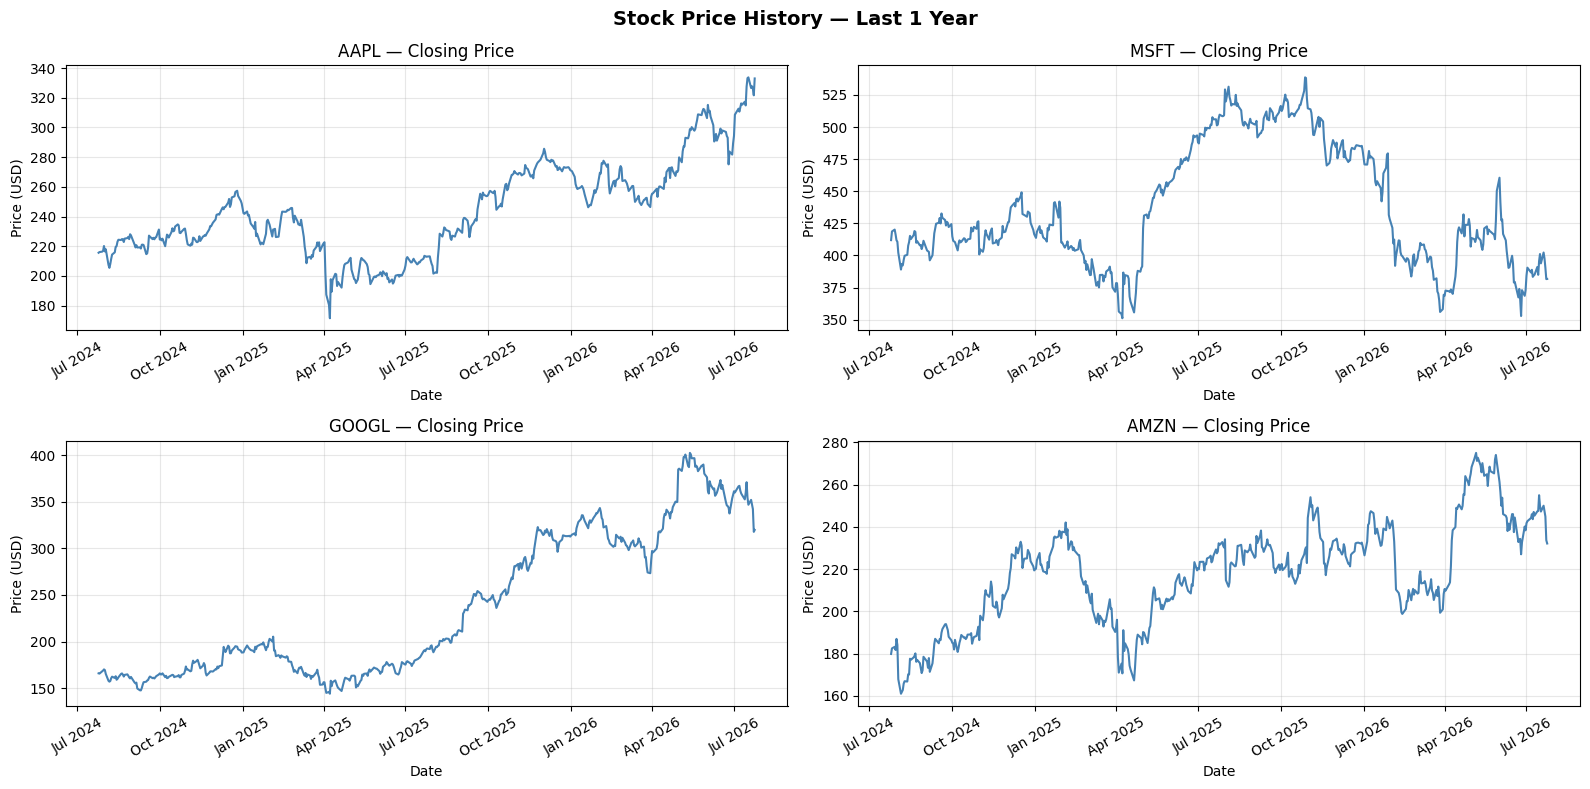

Saved: data/plots/01_price_history.png


In [6]:
# ── 1.3 Plot price history ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

# FIX: price_data is already flat (normalised in cell 1.1).
# Use ticker directly as column name — no MultiIndex check needed.
for i, ticker in enumerate(TICKERS):
    if ticker in price_data.columns:
        axes[i].plot(price_data.index, price_data[ticker], linewidth=1.5, color='steelblue')
        axes[i].set_title(f'{ticker} — Closing Price', fontsize=12)
        axes[i].set_xlabel('Date')
        axes[i].set_ylabel('Price (USD)')
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        axes[i].tick_params(axis='x', rotation=30)
    else:
        axes[i].text(0.5, 0.5, f'No data for {ticker}', ha='center', va='center')

plt.suptitle('Stock Price History — Last 1 Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plots/01_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/01_price_history.png')

In [7]:
# ── 1.4 Compute and plot daily returns ──────────────────────────────────────

# FIX: price_data is already flat — use it directly.
close_prices = price_data

# Daily returns
returns = close_prices.pct_change().dropna()
print('Returns shape:', returns.shape)
print('\nAnnualized return (approx):')
print((returns.mean() * 252 * 100).round(2).astype(str) + '%')

print('\nAnnualized volatility:')
print((returns.std() * np.sqrt(252) * 100).round(2).astype(str) + '%')

Returns shape: (500, 4)

Annualized return (approx):
AAPL     25.93%
AMZN     18.26%
GOOGL    37.94%
MSFT     -0.38%
dtype: object

Annualized volatility:
AAPL     28.47%
AMZN     32.91%
GOOGL    31.37%
MSFT     26.33%
dtype: object


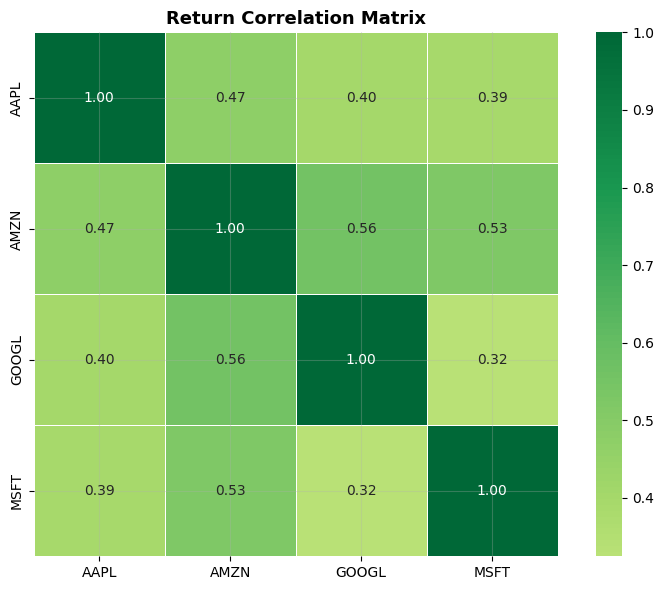

Saved: data/plots/01_correlation_matrix.png

Observation: High correlation = less diversification benefit


In [8]:
# ── 1.5 Correlation matrix ───────────────────────────────────────────────────
import seaborn as sns

corr = returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Return Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plots/01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/01_correlation_matrix.png')
print('\nObservation: High correlation = less diversification benefit')

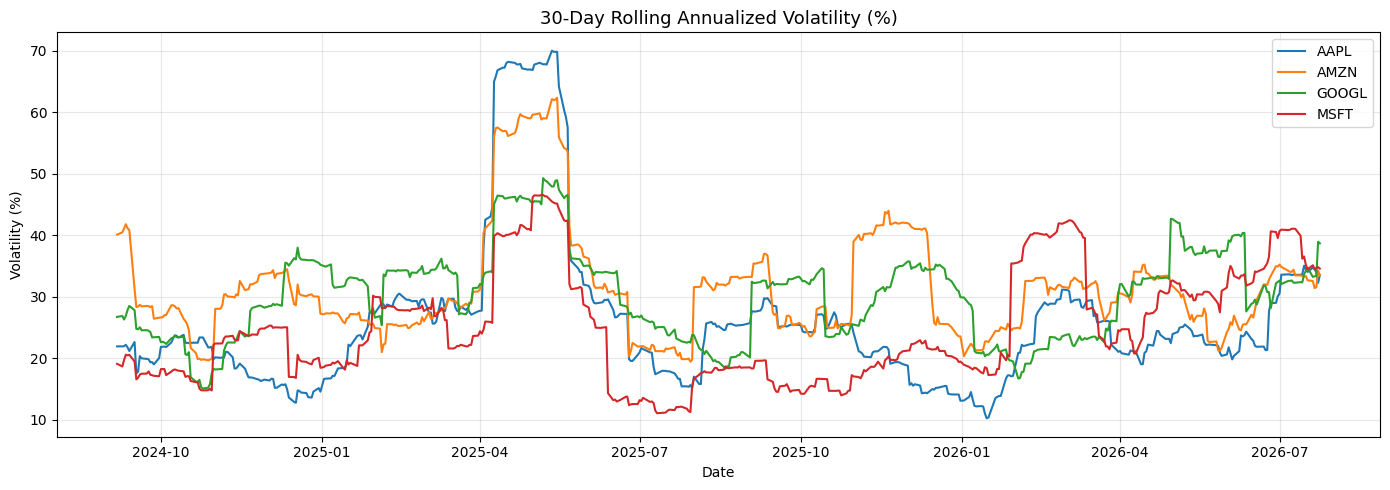

Saved: data/plots/01_rolling_volatility.png


In [9]:
# ── 1.6 Rolling 30-day volatility ────────────────────────────────────────────
rolling_vol = returns.rolling(30).std() * np.sqrt(252) * 100

plt.figure(figsize=(14, 5))
for col in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[col], label=col, linewidth=1.5)

plt.title('30-Day Rolling Annualized Volatility (%)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/plots/01_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/01_rolling_volatility.png')

---
## Section 2: News Data

In [10]:
# ── 2.1 Fetch news articles ──────────────────────────────────────────────────
from src.data.news_fetcher import fetch_news

all_news = {}
for ticker in TICKERS:
    articles = fetch_news(ticker)
    all_news[ticker] = articles
    print(f'{ticker}: {len(articles)} articles fetched')

2026-07-26 15:28:32,955 - INFO - Fetching news for AAPL (query: 'AAPL stock')
2026-07-26 15:28:34,650 - INFO - Found 18 articles for AAPL
2026-07-26 15:28:34,655 - INFO - Fetching news for MSFT (query: 'MSFT stock')


AAPL: 18 articles fetched


2026-07-26 15:28:35,369 - INFO - Found 19 articles for MSFT
2026-07-26 15:28:35,372 - INFO - Fetching news for GOOGL (query: 'GOOGL stock')


MSFT: 19 articles fetched


2026-07-26 15:28:36,036 - INFO - Found 19 articles for GOOGL
2026-07-26 15:28:36,038 - INFO - Fetching news for AMZN (query: 'AMZN stock')


GOOGL: 19 articles fetched


2026-07-26 15:28:36,748 - INFO - Found 19 articles for AMZN


AMZN: 19 articles fetched


In [11]:
# ── 2.2 Explore news structure ────────────────────────────────────────────────
# Show a sample article for AAPL
sample = all_news.get('AAPL', [])
if sample:
    print('Keys in article dict:', list(sample[0].keys()))
    print('\nSample article (AAPL #1):')
    print('  Title  :', sample[0].get('title', 'N/A'))
    # FIX: source can be a dict OR a plain string depending on NewsAPI version
    src = sample[0].get('source', {})
    src_name = src.get('name', 'N/A') if isinstance(src, dict) else str(src)
    print('  Source :', src_name)
    print('  Date   :', sample[0].get('publishedAt', sample[0].get('date', 'N/A')))
    desc = sample[0].get('description', sample[0].get('content', 'N/A'))
    desc_str = str(desc) if desc else 'N/A'
    print('  Desc   :', desc_str[:200] + '...' if len(desc_str) > 200 else desc_str)
else:
    print('No articles for AAPL — check NEWS_API_KEY in .env')

Keys in article dict: ['ticker', 'title', 'description', 'url', 'published_at', 'source', 'text']

Sample article (AAPL #1):
  Title  : Apple Stock Sends Major Warning Signal as Momentum Hits Peak
  Source : Barchart.com
  Date   : N/A
  Desc   : Apple's stock just triggered a rare technical signal not seen since 2020, and history suggests investors should pay close attention.


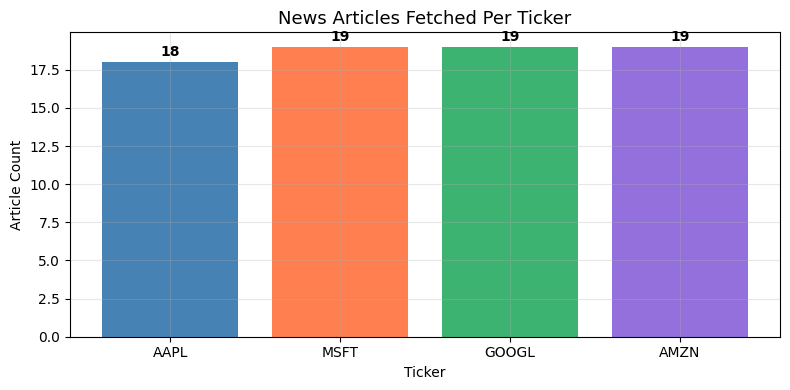


Total articles: 75
✅ Article coverage looks good


In [12]:
# ── 2.3 Article count per ticker ─────────────────────────────────────────────
counts = {ticker: len(articles) for ticker, articles in all_news.items()}

plt.figure(figsize=(8, 4))
bars = plt.bar(counts.keys(), counts.values(), color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
plt.title('News Articles Fetched Per Ticker', fontsize=13)
plt.ylabel('Article Count')
plt.xlabel('Ticker')
for bar, val in zip(bars, counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(val),
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plots/01_news_counts.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTotal articles:', sum(counts.values()))
if any(v < 3 for v in counts.values()):
    print('⚠️  WARNING: Some tickers have very few articles — sentiment may be unreliable')
else:
    print('✅ Article coverage looks good')

In [13]:
# ── 2.4 Check article title lengths (proxy for content quality) ───────────────
title_lengths = {}
for ticker, articles in all_news.items():
    lengths = [len(str(a.get('title', ''))) for a in articles if a.get('title')]
    title_lengths[ticker] = lengths
    avg = np.mean(lengths) if lengths else 0
    print(f'{ticker}: {len(lengths)} titles | avg length {avg:.0f} chars')

print('\nSample headlines per ticker:')
for ticker, articles in all_news.items():
    print(f'\n{ticker}:')
    for a in articles[:3]:
        title = a.get('title', 'No title')
        print(f'  - {title[:90]}')

AAPL: 18 titles | avg length 74 chars
MSFT: 19 titles | avg length 75 chars
GOOGL: 19 titles | avg length 69 chars
AMZN: 19 titles | avg length 74 chars

Sample headlines per ticker:

AAPL:
  - Apple Stock Sends Major Warning Signal as Momentum Hits Peak
  - Kraken parent expands tokenized stocks to Hong Kong, UK and South Korea equities
  - The Cost Pressure Apple Stock Stopped Flagging, And The New One That Should Worry You

MSFT:
  - Here’s Why Retail Investors Are Buying Microsoft (MSFT) on the Dip
  - Oracle stock has crashed 50% since June
  - The Trump Administration Just Gave Oklo Stock a Big Boost. Here's What to Know.

GOOGL:
  - Alphabet Earnings an Ideal Time to Get Acquainted With These ETFs
  - Oracle stock has crashed 50% since June
  - Alphabet earnings offer a moment of truth in this tech stock battle

AMZN:
  - Why AMZN Costs More Than Its Peer Group
  - Cloudflare Stock Is Not a Buy Despite Its Strong Outlook. Here’s Why.
  - Amazon Falls 4% as Senate China Probe and

---
## Section 3: FAISS Vector Store

In [14]:
# ── 3.1 Load existing FAISS index ─────────────────────────────────────────────
from src.data.vector_store import VectorStore

FAISS_PATH = '../data/faiss_index'
vs = VectorStore()

# FIX: Guard against missing index — build it fresh if it doesn't exist yet.
index_file = os.path.join(FAISS_PATH, 'index.faiss')
if os.path.exists(index_file):
    vs.load(path=FAISS_PATH)
    print('FAISS index loaded from disk.')
else:
    print('No saved index found — building from fetched news articles...')
    all_texts = []
    for ticker, articles in all_news.items():
        for article in articles:
            title = article.get('title', '')
            desc  = article.get('description', '')
            if title:
                all_texts.append(f'{ticker}: {title}. {desc}')
    vs.add_documents(all_texts)
    vs.save(path=FAISS_PATH)
    print(f'Built and saved new FAISS index with {len(all_texts)} documents.')

print('Total documents stored:', len(vs.documents))

2026-07-26 15:28:37,408 - INFO - Loading faiss with AVX2 support.
2026-07-26 15:28:37,409 - INFO - Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
2026-07-26 15:28:37,409 - INFO - Loading faiss.
2026-07-26 15:28:39,444 - INFO - Successfully loaded faiss.
2026-07-26 15:29:57,712 - INFO - Loading embedding model: all-MiniLM-L6-v2
2026-07-26 15:29:57,713 - INFO - First run downloads ~90MB — please wait...
2026-07-26 15:29:57,713 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2026-07-26 15:30:03,001 - INFO - Use pytorch device_name: cpu
2026-07-26 15:30:03,003 - INFO - Model loaded. Embedding dimension: 384
2026-07-26 15:30:03,009 - INFO - Loaded 77 articles from ../data/faiss_index


FAISS index loaded from disk.
Total documents stored: 77


In [15]:
# ── 3.2 Inspect stored documents ─────────────────────────────────────────────
print('Sample stored documents:')
for i, doc in enumerate(vs.documents[:5]):
    print(f'\n[{i}]', doc if isinstance(doc, str) else str(doc)[:150])

Sample stored documents:

[0] {'ticker': 'AAPL', 'title': 'Apple Stock Hits Record Territory as Traders Sour on AI Spending', 'description': 'Apple shares have rallied 15 percent s

[1] {'ticker': 'AAPL', 'title': 'Warren Buffett says he made the call for Berkshire to plow billions into Alphabet, but regrets not getting in earlier', '

[2] {'ticker': 'AAPL', 'title': 'Warren Buffett says he made the call for Berkshire to plow billions into Alphabet, but regrets not getting in earlier', '

[3] {'ticker': 'AAPL', 'title': 'AAPL stock rallies 15% as investors favor AI caution and welcome price increases', 'description': 'Apple stock slid signi

[4] {'ticker': 'AAPL', 'title': 'European "age verification" "app" forcing everyone to use Android or iOS', 'description': 'In the README, the following i


In [16]:
# ── 3.3 Semantic search test ──────────────────────────────────────────────────
test_queries = [
    'Apple iPhone sales revenue earnings',
    'Microsoft cloud Azure growth',
    'Google antitrust regulation legal',
    'Amazon AWS market share'
]

for query in test_queries:
    print(f'\nQuery: "{query}"')
    results = vs.search(query, k=2)
    for j, r in enumerate(results):
        text = r if isinstance(r, str) else str(r)
        print(f'  Result {j+1}: {text[:120]}...')


Query: "Apple iPhone sales revenue earnings"


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-07-26 15:30:03,073 - INFO - Search 'Apple iPhone sales revenue earnings' → 2 results


  Result 1: Apple Stock Hits Record Territory as Traders Sour on AI Spending. Apple shares have rallied 15 percent since their worst...
  Result 2: Apple Stock Hits Record Territory as Traders Sour on AI Spending. Apple shares have rallied 15 percent since their worst...

Query: "Microsoft cloud Azure growth"


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

2026-07-26 15:30:03,126 - INFO - Search 'Google antitrust regulation legal' → 2 results


  Result 1: Dear Google Stock Fans, Mark Your Calendars for July 13. Google Cloud's new U.K. regulatory designation on July 13 highl...
  Result 2: Walmart just restocked the Onn 4K Pro Google TV box, just not for everyone. Walmart’s Onn 4K Pro box with Google TV has ...

Query: "Amazon AWS market share"


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-07-26 15:30:03,151 - INFO - Search 'Amazon AWS market share' → 2 results


  Result 1: Amazon.com, Inc. (AMZN) Aims to Raise $25 billion from Bond Sale. Amazon.com, Inc. (NASDAQ:AMZN) is among the Ray Dalio ...
  Result 2: Amazon is clearing stock of the Samsung Galaxy Watch 8 with this absurd price cut on the 4.5-star smartwatch. With the G...


In [17]:
# ── 3.4 FAISS index metadata ──────────────────────────────────────────────────
import faiss

print('FAISS index info:')
print('  Total vectors:', vs.index.ntotal)
print('  Dimensions   :', vs.index.d)
print('  Index type   :', type(vs.index).__name__)
print('\n✅ Vector store is healthy and ready for RAG pipeline')

FAISS index info:
  Total vectors: 77
  Dimensions   : 384
  Index type   : IndexFlat

✅ Vector store is healthy and ready for RAG pipeline


---
## Section 4: Pipeline Integration Check

In [18]:
# ── 4.1 End-to-end: stock + news + vector search for one ticker ───────────────
print('End-to-end pipeline check for AAPL')
print('─' * 50)

# FIX: price_data is already flat after cell 1.1 — use ticker directly.
aapl_prices = price_data['AAPL'] if 'AAPL' in price_data.columns else price_data.iloc[:, 0]
print(f'[1] Stock data: {len(aapl_prices)} price points | latest close: ${aapl_prices.iloc[-1]:.2f}')

# 2. News articles
aapl_articles = all_news.get('AAPL', [])
print(f'[2] News articles: {len(aapl_articles)} fetched for AAPL')

# 3. Vector search
search_results = vs.search('Apple stock news earnings', k=3)
print(f'[3] FAISS search returned {len(search_results)} relevant articles')

print('\n✅ Data pipeline is fully operational. Ready for LLM layer.')

End-to-end pipeline check for AAPL
──────────────────────────────────────────────────
[1] Stock data: 501 price points | latest close: $333.02
[2] News articles: 18 fetched for AAPL


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-07-26 15:30:03,243 - INFO - Search 'Apple stock news earnings' → 3 results


[3] FAISS search returned 3 relevant articles

✅ Data pipeline is fully operational. Ready for LLM layer.


In [19]:
# ── 4.2 Portfolio-level return summary ───────────────────────────────────────
print('Portfolio Return Summary (Equal Weight)')
print('─' * 50)

eq_weight = 1 / len(TICKERS)
portfolio_returns = returns.mean(axis=1)  # Equal weight daily return

total_return = (1 + portfolio_returns).prod() - 1
ann_return = portfolio_returns.mean() * 252
ann_vol = portfolio_returns.std() * np.sqrt(252)
sharpe = ann_return / ann_vol if ann_vol != 0 else 0

print(f'Total Return  : {total_return*100:.2f}%')
print(f'Annual Return : {ann_return*100:.2f}%')
print(f'Annual Vol    : {ann_vol*100:.2f}%')
print(f'Sharpe Ratio  : {sharpe:.3f}')
print('\nThis baseline will be compared against Sharpe-optimized weights in Notebook 03.')

Portfolio Return Summary (Equal Weight)
──────────────────────────────────────────────────
Total Return  : 42.48%
Annual Return : 20.44%
Annual Vol    : 22.84%
Sharpe Ratio  : 0.895

This baseline will be compared against Sharpe-optimized weights in Notebook 03.


---
## Section 5: Summary & Data Quality Check

In [20]:
# ── 5.1 Final data quality summary ───────────────────────────────────────────
print('=' * 60)
print('DATA QUALITY SUMMARY')
print('=' * 60)

checks = {
    'Stock price data fetched': len(price_data) > 0,
    'No null prices': price_data.isnull().sum().sum() == 0,
    'News articles fetched': all(len(v) > 0 for v in all_news.values()),
    'FAISS index loaded': vs.index.ntotal > 0,
    'Semantic search working': len(search_results) > 0,
    'Returns computed': len(returns) > 0,
}

all_pass = True
for check, result in checks.items():
    status = '✅ PASS' if result else '❌ FAIL'
    if not result:
        all_pass = False
    print(f'  {status} — {check}')

print('\n' + ('✅ ALL CHECKS PASSED — Ready for Notebook 02 (sentiment analysis)'
              if all_pass else
              '❌ SOME CHECKS FAILED — Fix issues above before proceeding'))

DATA QUALITY SUMMARY
  ✅ PASS — Stock price data fetched
  ✅ PASS — No null prices
  ✅ PASS — News articles fetched
  ✅ PASS — FAISS index loaded
  ✅ PASS — Semantic search working
  ✅ PASS — Returns computed

✅ ALL CHECKS PASSED — Ready for Notebook 02 (sentiment analysis)
